On test les Grad-CAM sur nos réseaux (https://arxiv.org/abs/1610.02391)

In [1]:
from retinotopy import *
from gradcam import *

Running on GPU :  Quadro RTX 5000 #GPU= 1
------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host neo-ope-de04 with device cuda, pytorch==2.1.2+cu121
------------------------------------------------------------------------------------------------
Welcome on Linux-6.2.0-39-generic-x86_64-with-glibc2.35
Random seed 1998 has been set.
Running on GPU :  Quadro RTX 5000 #GPU= 1


In [2]:
# The dataset to import images from

data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use
args.resolution = (7,7)
args.do_polar = False
args.do_mask = False
BUG ?? image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)

exp_name = f'_complete_gradcam.parquet'

In [3]:
print('Lets go !')
#for model_data_set_type in data_set_types:
for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')

        print(f'{args.do_polar=}')

        print(50*'.')
        
        model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, args.do_polar) + '.pt'

        model_filename = None if model_data_set_type == 'raw' else model_filename
        
        model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
        
        annotations = get_annotation('csv')

        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, args.do_polar) + f'_complete_gradcam.parquet'
        print(df_filename)
        
        if os.path.isfile(df_filename):
            continue
        else:
            df_grad = None
            
            for i_image, (images, label) in tqdm(enumerate(image_datasets)):
            
                image_name = image_datasets.samples[i_image][0].split('/')[-1].split('.')[0]
                ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
                
                if ground_true.min() == 0.0:
                            
                    images = images.to(device)
                    
                    since_grad = time.time()
                    
                    GradCam, pred = get_Grad_cam(model, images.unsqueeze(0), label)
        
                    elapsed_time_grad = time.time() - since_grad
        
                    arg_max_prior = torch.argmax(GradCam).item()
                    
        
                    GradCam = GradCam.reshape(args.resolution[0]*args.resolution[1])
        
                    
                    position_prior = (arg_max_prior%args.resolution[0], arg_max_prior//args.resolution[1])
        
                    mid_point, in_point, ext_point = get_like_point(GradCam, args.resolution, three_points)
                    
                    grad_out = th_delete(GradCam, ground_true_indices[0])
            
                    grad_out_max = torch.max(grad_out).item()
                    grad_in_max = torch.max(GradCam[ground_true_indices[0]]).item()
                
                    grad_out_mean = torch.mean(grad_out).item()
                    grad_in_mean = torch.mean(GradCam[ground_true_indices[0]]).item()
        
                    
                    Iou = get_IoU(GradCam, ground_true.reshape(args.resolution[0]*args.resolution[1]))
        
                    
        
                    PG = 1 if grad_in_max > grad_out_max else 0
                    
                    
                    df_grad_ = pd.DataFrame({'image_name':image_name, 'grad_in_max': grad_in_max, 'grad_out_max': grad_out_max,
                                             'grad_in_mean': grad_in_mean, 'grad_out_mean': grad_out_mean, 'position_prior':[position_prior],
                                             'Iou':[Iou], 'PG':PG,  'in_point':in_point.item(), 'mid_point':mid_point.item(), 'ext_point':ext_point.item(),
                                             'pred':pred, 'time_grad':elapsed_time_grad, 'label':label, 'GradCam':[np.asarray(GradCam)]})
                
                    df_grad = store_pandas(df_grad, df_grad_)
            
            df_grad.to_parquet(df_filename)
            model.cpu()

Lets go !
model_data_set_type='raw'
..................................................
args.do_polar=False
..................................................
cached_data/2024-05-24_raw_resnet18_cartesian_complete_gradcam.parquet
..................................................
args.do_polar=False
..................................................
cached_data/2024-05-24_raw_resnet50_cartesian_complete_gradcam.parquet
..................................................
args.do_polar=False
..................................................
cached_data/2024-05-24_raw_resnet101_cartesian_complete_gradcam.parquet
model_data_set_type='full'
..................................................
args.do_polar=False
..................................................
loading .... cached_data/2024-05-24_full_resnet18_cartesian.pt
cached_data/2024-05-24_full_resnet18_cartesian_complete_gradcam.parquet
..................................................
args.do_polar=False
.............................

In [4]:
def get_pandas_cam(model_data_set_type, model_name, exp_name):
    
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + exp_name
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
        
    return df

In [5]:
#for model_data_set_type in data_set_types: # data_set_types
for model_data_set_type in ['full', 'bbox', 'focus', 'raw']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
    #for model_name in ['resnet18']:
        print(f'{model_name=}')    
        print(50*'.')


        
        args.do_polar = False
        print(f'{args.do_polar=}')
        print(50*'.')

        
        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + exp_name
        results = pd.read_parquet(df_filename)
        
        print(results['grad_in_mean'].mean(), 'grad_in_mean')
        print(results['grad_out_mean'].mean(), 'grad_out_mean')
        print(results['grad_in_mean'].mean()/results['grad_out_mean'].mean(), 'likelihood ratio')
        print(results['grad_in_max'].mean(), 'grad_in_max')
        print(results['grad_out_max'].mean(), 'grad_out_max')
        
        
        print(results['mid_point'].mean(), 'mid_point')
        print(results['in_point'].mean(), 'in_point')
        print(results['ext_point'].mean(), 'ext_point')

        mean_Iou = read_IoU(results['Iou'])
        print(mean_Iou[0], 'mean IoU')

        best_Iou = get_best_Iou(results['Iou'], np.argmax(mean_Iou[0]))
        
        for test_tresh in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
            inpel = 0
            for i, j in enumerate(results['grad_in_max']):
                #print(i, j, results['max_in_heat'][i] , '>', results['max_out_heat'][i])
                if best_Iou[i] > test_tresh and results['label'][i] == results['pred'][i]:
                    inpel += 1
            print(inpel/len(results['grad_in_max']), f'GT-known : {test_tresh}')
    
        
        
        print(results['PG'].mean(), 'PG')
        


model_data_set_type='full'
model_name='resnet18'
..................................................
args.do_polar=False
..................................................
0.615936711987402 grad_in_mean
0.2718993883512487 grad_out_mean
2.2653111348368107 likelihood ratio
0.9745601554083426 grad_in_max
0.6728127897164554 grad_out_max
0.7637118203134161 mid_point
0.4528492564744057 in_point
0.12962813873575554 ext_point
{0: 0.43333054287464745, 1: 0.4523531175595213, 2: 0.4763538123143746, 3: 0.49652029605278486, 4: 0.5106983760177406, 5: 0.5191885400479763, 6: 0.5218317864281885, 7: 0.5188150176333236, 8: 0.5098622864710486, 9: 0.4953136551764316, 10: 0.4750832874674571, 11: 0.44897265737097797, 12: 0.41648760540011187, 13: 0.37966725196853723, 14: 0.3374949505121745, 15: 0.29102642661251515, 16: 0.24260430830731583, 17: 0.19341418490512916, 18: 0.146307105573536, 19: 0.10270243889143707, 20: 0.0} mean IoU
0.6850363907498498 GT-known : 0
0.6297714171247969 GT-known : 0.1
0.55872598989516

model_data_set_type='raw'
model_data_set_type='full'
model_data_set_type='bbox'


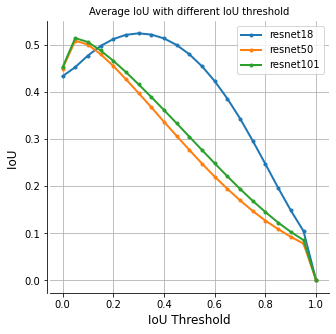

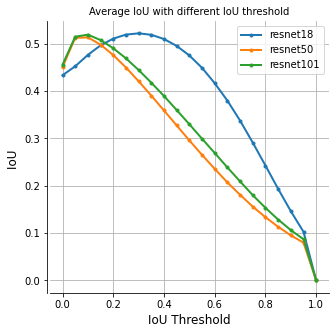

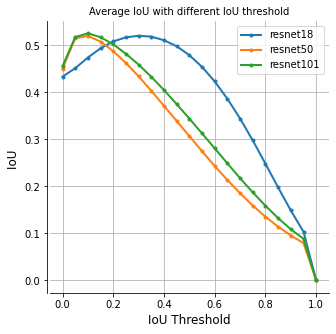

In [6]:
#subplotpars = matplotlib.figure.SubplotParams(left=0.1, right=.95, bottom=0.25, top=.975, hspace=.6)
#data_set_types.append('raw')
for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    df_list = []
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        
        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + exp_name
        df_list.append(pd.read_parquet(df_filename))


    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plt.tick_params(axis='both', which='major', labelsize=10)
    
    for df_, label in zip(df_list, ['resnet18', 'resnet50', 'resnet101']):
    
        mean_Iou, list_Iou = read_IoU(df_['Iou'])
    
    
        ax.plot(np.linspace(0, 1, 21), list_Iou, lw=2, marker='.', label=label)
        ax.set_xlabel(f"IoU Threshold", size=12)
        ax.set_ylabel(f"IoU ", size=12)
        ax.spines['left'].set_position(('axes', -0.01))
        #ax.set_yscale("logit", one_half="1/2", use_overline=True)
        ax.grid(which='both')
        ax.legend()
        for side in ['top', 'right'] :ax.spines[side].set_visible(False)
        ax.set_title(f'Average IoU with different IoU threshold', size=10);

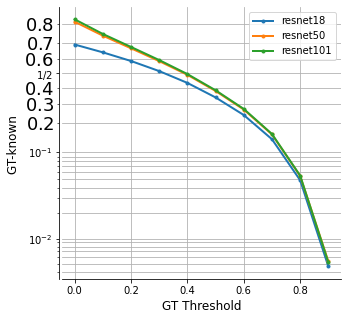

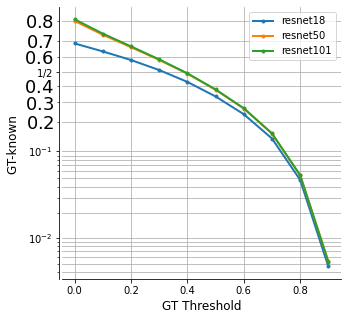

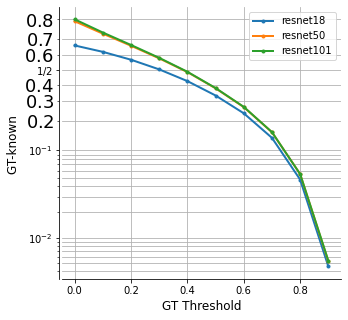

In [7]:
for model_data_set_type in data_set_types:
   
    df_list = []
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        
        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + exp_name
        df_list.append(pd.read_parquet(df_filename))


    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plt.tick_params(axis='both', which='major', labelsize=10)
    GT = {}
    for df_, label in zip(df_list, ['resnet18', 'resnet50', 'resnet101']):
    
        GT[label] = []
        for test_tresh in np.linspace(0, 0.9, 10):
            inpel = 0
            for i, j in enumerate(df_['grad_in_max']):
                if best_Iou[i] > test_tresh and df_['label'][i] == df_['pred'][i]:
                    inpel += 1
            GT[label].append(inpel/len(df_['grad_in_max']))

        ax.plot(np.asarray(np.linspace(0, 0.9, 10)), GT[label], lw=2, marker='.', label=label)
        ax.set_xlabel(f"GT Threshold", size=12)
        ax.set_ylabel(f"GT-known ", size=12)
        ax.spines['left'].set_position(('axes', -0.01))
        ax.set_yscale("logit", one_half="1/2", use_overline=True)
        ax.grid(which='both')
        ax.legend()
        for side in ['top', 'right'] :ax.spines[side].set_visible(False)

In [8]:
df_filename = f"{data_cache}/get_distance_to_plot_cam.parquet"
results = pd.read_parquet(df_filename)
distance_plot = np.concatenate([np.zeros(len(results['Distance_0'])), np.asarray(results['Distance_0']), np.asarray(results['Distance_1'])])
distance_plot = normalize_array(distance_plot)

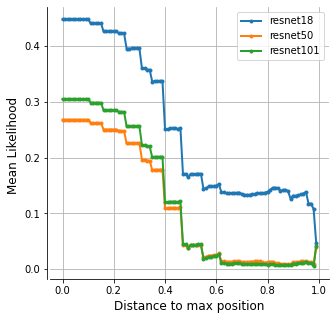

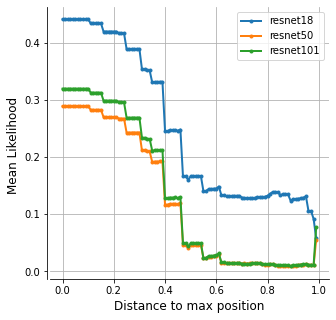

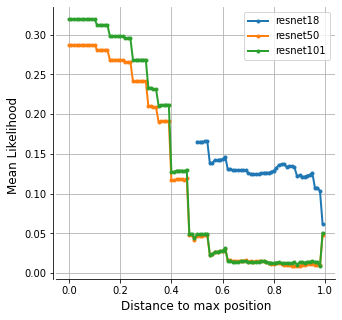

In [9]:
for model_data_set_type in data_set_types:
    df_list = []
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        
        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + exp_name
        df_list.append(pd.read_parquet(df_filename))


    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plt.tick_params(axis='both', which='major', labelsize=10)
    
    for df_, label in zip(df_list, ['resnet18', 'resnet50', 'resnet101']):
    
        list_dist = []
            
        likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['mid_point']), np.array(df_['ext_point'])])
        
        new_likelihood_plot = []
        for i in np.linspace(0, .99, 100 ):
            new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
    
    
    
        ax.plot(np.linspace(0, .99, 100 ), new_likelihood_plot, lw=2, marker='.', label=label)
        ax.set_xlabel(f"Distance to max position", size=12)
        ax.set_ylabel(f"Mean Likelihood ", size=12)
        ax.spines['left'].set_position(('axes', -0.01))
    
        ax.grid(which='both')
        ax.legend()
        for side in ['top', 'right'] :ax.spines[side].set_visible(False)

df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet18_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet50_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_complete_gradcam.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_complete_gradcam.parquet'


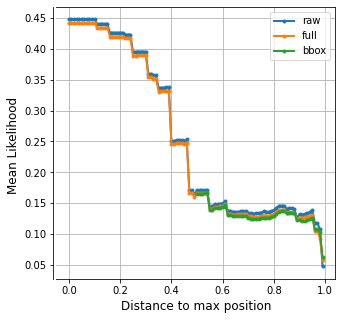

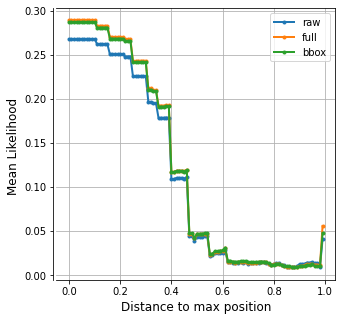

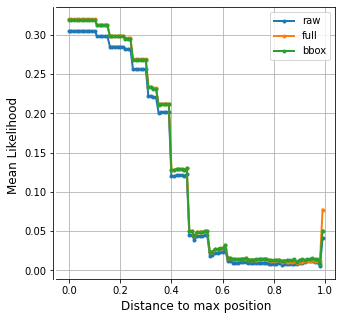

In [10]:
#for model_data_set_type in ['bbox']:
dfs = []
for model_name in  ['resnet18', 'resnet50', 'resnet101']:
    
    for model_data_set_type in data_set_types:   
        dfs.append(get_pandas_cam(model_data_set_type, model_name, exp_name))
    

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plt.tick_params(axis='both', which='major', labelsize=10)
        
    for df_, label in zip(dfs, data_set_types):

        
        list_dist = []
        likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['mid_point']), np.array(df_['ext_point'])])

        
        new_likelihood_plot = []
        for i in np.linspace(0, .99, 100 ):
            new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
    
        ax.plot(np.linspace(0, .99, 100 ), new_likelihood_plot, lw=2, marker='.', label=label)
        ax.set_xlabel(f"Distance to max position", size=12)
        ax.set_ylabel(f"Mean Likelihood ", size=12)
        ax.spines['left'].set_position(('axes', -0.01))
    
        ax.grid(which='both')
        ax.legend()


    dfs = []
                        
            
